# Artin Tavasoli - 810102543


### Libraries

In [193]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

### Configurations

In [194]:
random_state = 29
missing_drop_threshold = 15.0
z_thresh = 3.0 
train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15
batch_size = 32
learning_rate = 0.0001
epochs = 200


In [ ]:
torch.manual_seed(random_state)

### Loading data

In [196]:
import pandas as pd

df = pd.read_csv('Life Expectancy Data.csv')

df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()

print(df.head())


       country  year      status  life_expectancy  adult_mortality  \
0  Afghanistan  2015  Developing             65.0            263.0   
1  Afghanistan  2014  Developing             59.9            271.0   
2  Afghanistan  2013  Developing             59.9            268.0   
3  Afghanistan  2012  Developing             59.5            272.0   
4  Afghanistan  2011  Developing             59.2            275.0   

   infant_deaths  alcohol  percentage_expenditure  hepatitis_b  measles  ...  \
0             62     0.01               71.279624         65.0     1154  ...   
1             64     0.01               73.523582         62.0      492  ...   
2             66     0.01               73.219243         64.0      430  ...   
3             69     0.01               78.184215         67.0     2787  ...   
4             71     0.01                7.097109         68.0     3013  ...   

   polio  total_expenditure  diphtheria  hiv/aids         gdp  population  \
0    6.0             

### Outlier Handling

We identified and removed outliers from a training dataset based on the Z-score method. 
The function loops through every column in `X_train`. It intentionally skips the `year` and `status` columns, because Z-score outlier detection doesn't make statistical sense.

   It computes the absolute Z-score for every value in the column using the formula:
   $$Z = \frac{|X - \mu|}{\sigma}$$
   * *Edge Case Handling*: If the standard deviation is exactly $0$ (meaning all values in the column are identical), it assigns a Z-score of $0$ to avoid a division-by-zero error.
   
It filters the indices of the rows where the calculated Z-score is greater than or equal to `z_thresh` ($Z \ge z\_thresh$) and adds these indices to the `outliers` set (we set the thresh to 3 in config, so with guassian assumptian it captures 99% of data)

In [197]:
def handle_outliers(X_train, y_train, z_thresh):
    outliers = set() 
    
    for col in X_train.columns:
        if col in ['year', 'status']:
            continue
            
        mean_val = X_train[col].mean()
        std_val = X_train[col].std(ddof=0)
 
        diff = abs(X_train[col] - mean_val)
        
        if std_val == 0:
             z_scores = pd.Series(0, index=X_train.index)
        else:
            z_scores = diff / std_val
        
        outlier_indices = X_train[z_scores >= z_thresh].index
        outliers.update(outlier_indices)
        
    X_clean = X_train.drop(index=list(outliers))
    y_clean = y_train.drop(index=list(outliers))
    
    return X_clean, y_clean

### Data Preprocessing

1. Target Variable Cleaning: 
   Drop any rows where the target variable (`life_expectancy`) is missing.

2. Feature Selection & Encoding:
  `country` feature shouldn't be a factor in life expectancy model because if a new data comes from a new country it will act badly.
  this is because this features values are not related and have no order. 
   also convert the categorical `status` column into numerical values using Label Encoding.

3. Data Splitting: 
   Separate the dataset into features ($X$) and the target ($y$), and then split them into Training, Validation, and Testing sets based on predefined ratios.

4. Outlier Handling: 

5. Handling Missing Values:
   * Column Dropping: Calculates the percentage of missing values for each feature in the training set. If a feature exceeds a certain threshold, that column is completely removed from all splits (Train, Val, Test).
   * Mean Imputation: Fills any remaining missing values in the datasets using the mean values calculated from the training set.

6. Feature and Target Scaling: 
   Standardizes both the features ($X$) and the target variable ($y$) to have a mean of $0$ and a standard deviation of $1$ ($\mu=0, \sigma=1$). The scalers are fitted only on the training data and then used to transform the training, validation, and test sets.
   the reason why we scale $y$ is because it's range is around 40-90 and it takes a let of steps for the network that is usually initialized to small amounts to get there (we return `scaler_y` so that we can transform back to the original scale for evaluation.)


In [198]:
def preprocess(df):
    data = df.copy()
    
    data = data.dropna(subset=['life_expectancy'])
    
    if 'country' in data.columns:
        data = data.drop(columns=['country'])
        
    le_status = LabelEncoder()
    data['status'] = le_status.fit_transform(data['status'])
    
    X = data.drop(columns=['life_expectancy'])
    y = data['life_expectancy']
    
    test_and_val_ratio = val_ratio + test_ratio
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=test_and_val_ratio, random_state=random_state)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=test_ratio / test_and_val_ratio, random_state=random_state)
    
    X_train, y_train = handle_outliers(X_train, y_train, z_thresh)
    
    cols_to_drop = []
    for col in X_train.columns:
        missing_percentage = (X_train[col].isnull().sum() / len(X_train)) * 100
        if missing_percentage > missing_drop_threshold:
            cols_to_drop.append(col)
            
    X_train = X_train.drop(columns=cols_to_drop)
    X_val = X_val.drop(columns=cols_to_drop)
    X_test = X_test.drop(columns=cols_to_drop)
    
    train_means = X_train.mean()
    X_train = X_train.fillna(train_means)
    X_val = X_val.fillna(train_means)
    X_test = X_test.fillna(train_means)
    


    scaler_X = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler_X.fit_transform(X_train), index=X_train.index, columns=X_train.columns)
    X_val_scaled = pd.DataFrame(scaler_X.transform(X_val), index=X_val.index, columns=X_val.columns)
    X_test_scaled = pd.DataFrame(scaler_X.transform(X_test), index=X_test.index, columns=X_test.columns)

    scaler_y = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
    y_val_scaled = scaler_y.transform(y_val.values.reshape(-1, 1)).flatten()
    y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()
    
    y_train = pd.Series(y_train_scaled, index=y_train.index)
    y_val = pd.Series(y_val_scaled, index=y_val.index)
    y_test = pd.Series(y_test_scaled, index=y_test.index)

    print("Original dataframe size:", df.shape)
    print("Train features size:", X_train_scaled.shape)
    
    return X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test, scaler_y

In [199]:
X_train_df, y_train_df, X_val_df, y_val_df, X_test_df, y_test_df, scaler_y = preprocess(df)

print("Preprocessed training data:")
print("x train head: \n", X_train_df.head())
print("y train head: \n", y_train_df.head())

X_train = torch.tensor(X_train_df.values, dtype=torch.float32)
y_train = torch.tensor(y_train_df.values, dtype=torch.float32).view(-1, 1)

X_val = torch.tensor(X_val_df.values, dtype=torch.float32)
y_val = torch.tensor(y_val_df.values, dtype=torch.float32).view(-1, 1)

X_test = torch.tensor(X_test_df.values, dtype=torch.float32)
y_test = torch.tensor(y_test_df.values, dtype=torch.float32).view(-1, 1)

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

val_dataset = TensorDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

Original dataframe size: (2938, 22)
Train features size: (1624, 17)
Preprocessed training data:
x train head: 
           year    status  adult_mortality  infant_deaths   alcohol  \
179   0.951520  0.444567        -0.780739      -0.478025 -0.752401   
2046  0.077252 -2.249378        -1.310620      -0.410701  1.759356   
948   1.170087  0.444567         0.929753      -0.410701  1.101639   
1519 -1.234150  0.444567        -0.083528      -0.377039 -1.190016   
477  -1.234150  0.444567         1.097083       0.296200 -0.822315   

      percentage_expenditure   measles       bmi  under-five_deaths     polio  \
179                 1.889816 -0.295552  1.130356          -0.476034  0.775004   
2046               -0.452724 -0.295552  0.911069          -0.404099  0.562759   
948                -0.304243 -0.260329 -0.210862          -0.404099 -0.781459   
1519               -0.438406  0.827558  0.747879          -0.404099  0.350514   
477                -0.436510  0.097392 -1.353192           0.2

we had 18 feautures after preprocessing which 1 of them was target so input dimension is 17

In [200]:
input_dim = X_train.shape[1]
print("input dimension is: ", input_dim)

input dimension is:  17


In [201]:
class Reg_V1(nn.Module):
    def __init__(self, input_size, h1=16):
        super(Reg_V1, self).__init__()
        self.reg = nn.Sequential(
            nn.Linear(input_size, h1),
            nn.ReLU(),
            nn.Linear(h1, 1)
        )
    def forward(self, x):
        return self.reg(x)

class Reg_V2(nn.Module):
    def __init__(self, input_size, h1=16, h2=8):
        super(Reg_V2, self).__init__()
        self.reg = nn.Sequential(
            nn.Linear(input_size, h1),
            nn.ReLU(),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Linear(h2, 1)
        )
    def forward(self, x):
        return self.reg(x)

In [202]:
def count_parameters(model):
    cnt = 0
    for param in model.parameters():
        if param.requires_grad:
            cnt += param.numel()
    return cnt

In [203]:
def train_model(model, train_loader, val_loader, epochs=epochs, lr=learning_rate):
    criterion = nn.MSELoss() 
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        model.train()
        total_epoch_train_loss = 0.0
        train_samples = 0
        
        for inputs, targets in train_loader:
            optimizer.zero_grad() 
            outputs = model(inputs) 
            loss = criterion(outputs, targets) 
            loss.backward() 
            optimizer.step() 
            
            total_epoch_train_loss += loss.item() * inputs.size(0)
            train_samples += inputs.size(0)
            
        avg_epoch_train_loss = total_epoch_train_loss / train_samples
        train_losses.append(avg_epoch_train_loss)
        
        model.eval()
        total_epoch_val_loss = 0.0
        val_samples = 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                
                total_epoch_val_loss += loss.item() * inputs.size(0)
                val_samples += inputs.size(0)
                
        avg_epoch_val_loss = total_epoch_val_loss / val_samples
        val_losses.append(avg_epoch_val_loss)
        
    return train_losses, val_losses

In [204]:
model_V1 = Reg_V1(input_dim)
model_V2 = Reg_V2(input_dim)
print("Total number of parameters for the first model: ", count_parameters(model_V1))
print("Total number of parameters for the second model: ", count_parameters(model_V2))
train_loss_1, val_loss_1 = train_model(model_V1, train_loader, val_loader, epochs=epochs)
train_loss_2, val_loss_2 = train_model(model_V2, train_loader, val_loader, epochs=epochs)

Total number of parameters for the first model:  305
Total number of parameters for the second model:  433


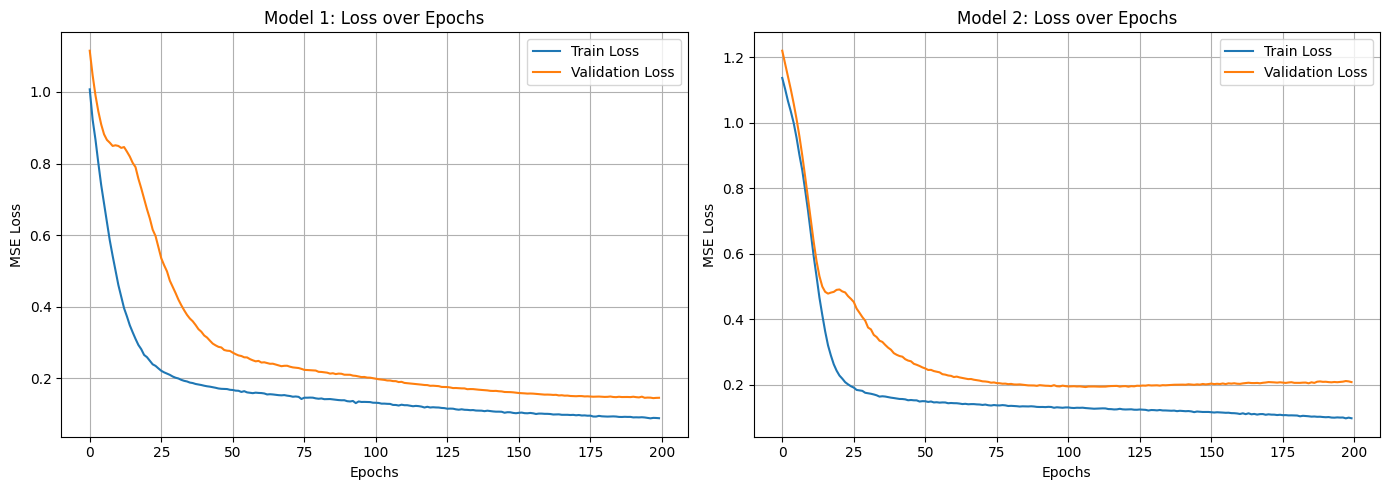

In [205]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss_1, label='Train Loss')
plt.plot(val_loss_1, label='Validation Loss')
plt.title('Model 1: Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_loss_2, label='Train Loss')
plt.plot(val_loss_2, label='Validation Loss')
plt.title('Model 2: Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 1. Mean Squared Error (MSE)
MSE measures the average of the squares of the errors (the difference between the actual and predicted values).

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

### 2. Root Mean Squared Error (RMSE)
RMSE is simply the square root of the MSE. It brings the error metric back to the same unit as the target variable, making it easier to interpret.

$$RMSE = \sqrt{MSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

### 3. Coefficient of Determination ($R^2$)
An $R^2$ of $1$ indicates perfect predictions.

$$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$

**Where:**
*   $n$ is the total number of samples (observations).
*   $y_i$ is the actual (true) value of the target for the $i$-th sample.
*   $\hat{y}_i$ is the predicted value for the $i$-th sample.
*   $\bar{y}$ is the mean (average) of all actual true values, calculated as: $\bar{y} = \frac{1}{n} \sum_{i=1}^{n} y_i$

In [206]:
def evaluate_model(model, model_name, x, y, scaler_y):
    model.eval()
    with torch.no_grad():
        y_hat_scaled = model(x)

        mean = torch.tensor(scaler_y.mean_, dtype=torch.float32)
        scale = torch.tensor(scaler_y.scale_, dtype=torch.float32)

        y_hat_real = y_hat_scaled * scale + mean
        y_real = y * scale + mean

        mse = torch.mean((y_hat_real - y_real) ** 2).item()
        rmse = mse ** 0.5
        
        sum_squared_samples = torch.sum((y_real - y_hat_real) ** 2)
        sum_squared_avg_samples = torch.sum((y_real - torch.mean(y_real)) ** 2)
        r2 = (1 - (sum_squared_samples / sum_squared_avg_samples)).item()
    
    print(f"Evaluation results for {model_name}")
    print(f"MSE:  ${mse:.4f}$")
    print(f"RMSE: ${rmse:.4f}$")
    print(f"R^2:  ${r2:.4f}$")


In [207]:
evaluate_model(model_V1, "first model (1 hidden layer)", X_test, y_test, scaler_y)
evaluate_model(model_V2, "second model (2 hidden layers)", X_test, y_test, scaler_y)

Evaluation results for first model (1 hidden layer)
MSE:  $13.3558$
RMSE: $3.6546$
R^2:  $0.8566$
Evaluation results for second model (2 hidden layers)
MSE:  $12.8045$
RMSE: $3.5783$
R^2:  $0.8625$


In [208]:
class Reg_Advanced(nn.Module):
    def __init__(self, input_size, h1=64, h2=32, h3=8, dropout_rate=0.2):
        super(Reg_Advanced, self).__init__()
        
        self.reg = nn.Sequential(
            nn.Linear(input_size, h1),
            nn.BatchNorm1d(h1),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(h1, h2),
            nn.BatchNorm1d(h2),
            nn.ReLU(),
            nn.Dropout(dropout_rate * 0.8),  
            
            nn.Linear(h2, h3),
            nn.ReLU(),
            nn.Dropout(dropout_rate * 0.6),

            nn.Linear(h3, 1)
        )
    
    def forward(self, x):
        return self.reg(x)


Total number of parameters for the advance model:  3697


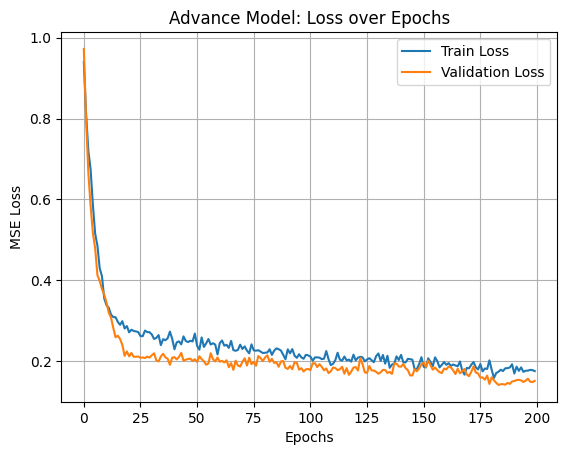

Evaluation results for advance model
MSE:  $10.5086$
RMSE: $3.2417$
R^2:  $0.8872$


In [209]:
model_V3 = Reg_Advanced(input_dim)
print("Total number of parameters for the advance model: ", count_parameters(model_V3))
train_loss_3, val_loss_3 = train_model(model_V3, train_loader, val_loader, epochs=epochs)
plt.figure()
plt.plot(train_loss_3, label='Train Loss')
plt.plot(val_loss_3, label='Validation Loss')
plt.title('Advance Model: Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()
evaluate_model(model_V3, "advance model", X_test, y_test, scaler_y)